In [2]:
#All packages needed to run TwINFER simulation and inference are listed here. 
#If any of them are not installed, please install them using pip or conda env.
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numba
import tqdm
import scipy
import seaborn
import os
import sys
import joblib
from itertools import product
import joblib 
import importlib


# Code to simulate a synthetic GRN and infer the network using TwINFER


## Details about the simulation

### Set this for both running the simulation and before inferring using TwINFER


In [1]:
#Path to TwINFER code repository
import os, sys
path_to_code_repo = os.path.abspath(getattr(sys.modules['__main__'], '__file__', os.getcwd()))


# #Common path to data files
# path_to_data = f"{path_to_code_repo}/simulation_example_input_data"
# path_to_output = f"{path_to_code_repo}/simulation_example_output_data"

# base_config = {
#     'n_cells': 6000, #Number of cells before division (number of twin pairs)
#     'simulation_time_before_division': 100, #The time used to run the initial cells before division. User must set this time to ensure the population reaches steady state [hours]
#     'twin_simulation_time_after_division': 48, #The time twin cells are simulated after division and measurements are stored in the output[hours]
#     'twin_measurement_resolution': 1, #The time between each measurement of twin cells [hours]. For example, if twin_sampling_duration is 12 and twin_measurement_resolution is 1, the final dataframe will contain hourly measurements for 12 hours (0 is birth).
#     "path_to_connectivity_matrix": f"{path_to_data}/connectivity_matrix_A_to_B.txt", #path to the connectivity matrix specifying the GRN to simulate
#     "param_csv": f"{path_to_data}/median_parameter.csv", #Path to the parameters for all genes and interaction terms
#     "rows_to_use": [[0, 0]], #Rows in the parameter's csv file for each gene. Example - [0,0] will mean use row 0 parameters for both gene 1 and 2. The length should be equal to number of genes in the system. Ensure that each row in the parameter.csv has unique index.
#     "output_folder": f"{path_to_output}", #Path to the output folder
#     "log_file": f"{path_to_output}/log.jsonl", #Path to the log file
#     "type": "A_to_B",  # Name of the network used -- will be in the filename
#     "number_of_parallel_parameters": 1, #Number of parameters to be run in parallel
#     "number_of_cores_per_parameter": 2, #Number of cores to be used per parameter (number_of_parallel_parameters * number_of_cores_per_parameter = number of cores in your computer)
# }
protein_1 = 29965.104
protein_2 = 119763.6917
K_matrix = [[0, protein_1, protein_1], [0,0, protein_2], [0,0,0]]
path_to_output = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_new"
        
base_config= {
            'n_cells': 6000, #Number of cells before division (number of twin pairs)
            'simulation_time_before_division': 6000, #The time used to run the initial cells before division. User must set this time to ensure the population reaches steady state [hours]
            'twin_simulation_time_after_division': 24, #The time twin cells are simulated after division and measurements are stored in the output[hours]
            'twin_measurement_resolution': 1, #The time between each measurement of twin cells [hours]. For example, if twin_sampling_duration is 12 and twin_measurement_resolution is 1, the final dataframe will contain hourly measurements for 12 hours (0 is birth).
            "path_to_connectivity_matrix": "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER-main 3/Matrix/Fan_out_example12.txt", #path to the connectivity matrix specifying the GRN to simulate
            "param_csv": f"/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/simulation_example_input_data/median_parameter.csv", #Path to the parameters for all genes and interaction terms
            "rows_to_use": [[3]*3], #Rows in the parameter's csv file for each gene. Example - [0,0] will mean use row 0 parameters for both gene 1 and 2. The length should be equal to number of genes in the system. Ensure that each row in the parameter.csv has unique index.
            "output_folder": f"{path_to_output}", #Path to the output folder
            "log_file": f"{path_to_output}/and_or_simulation.log",  # Name of the network used -- will be in the filename
            "log_pi_on": False,
            "multiple_interaction_type": "additive_new",
            "type": "Fan_out_additive_new_n_1",  # Name of the network used -- will be in the filename
            "use_given_K": False,
            "number_of_parallel_parameters": 1, #Number of parameters to be run in parallel
            "number_of_cores_per_parameter": 8, #Number of cores to be used per parameter (number_of_parallel_parameters * number_of_cores_per_parameter = number of cores in your computer)
        }

# protein_1 = 29965.104
# protein_2 = 119763.6917
# K_matrix = [[0, protein_1, protein_1], [0,0, protein_2], [0,0,0]]
# base_config ={
#             'n_cells': 6000,
#             'simulation_time_before_division': 1500,
#             'twin_simulation_time_after_division': 24,
#             'twin_measurement_resolution': 1,
#             "path_to_connectivity_matrix": "/home/gzu5140/TwINFER-main 3/Matrix/Feed_forward_example10.txt",
#             "param_csv": "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER-main 3/simulation_example_input_data/Median_parameter.csv",
#             "rows_to_use": [[0] * 3],
#             "output_folder": "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/testing_hill/",
#             "log_file": "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/and_or_sim/logs/Mutual_regulation_median_or.log",
#             "type": "Feed_forward_median",
#             "multiple_interaction_type": "additive",
#             "number_of_parallel_parameters": 1,
#             "number_of_cores_per_parameter": 12,
#             "use_given_K":True,
#             "K_to_use":K_matrix,
#             "log_pi_on": True,
#         }

## Functions and packages used in this notebook - run this everytime notebook is restarted


### For the simulation


In [3]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import set_num_threads, get_num_threads

sys.path.append(str(path_to_code_repo))
set_num_threads(base_config['number_of_cores_per_parameter'])
print("Threads Numba will use:", get_num_threads())

import importlib
from TwINFER_function_scripts import gillespie_script_variations
importlib.reload(gillespie_script_variations)
from TwINFER_function_scripts.gillespie_script_variations import process_param_set

Threads Numba will use: 8


### For inferring with TwINFER


In [15]:
# Calculation functions
import importlib
from TwINFER_function_scripts import correlation_analysis_functions
from TwINFER_function_scripts import correlation_analysis_helpers
from TwINFER_function_scripts import infer_with_twinfer

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)
importlib.reload(infer_with_twinfer)

from TwINFER_function_scripts.correlation_analysis_functions import (
    
    calculate_pairwise_gene_gene_correlation_matrix,
    check_system_in_steady_state,
    check_gene_gene_correlation_threshold,
    calculate_twin_random_pair_correlations,
    differentiate_single_state_reg_and_multiple_states,
    identify_reg_if_multiple_states,
    get_cross_correlations,
    identify_actual_directed_edges
)

# Helper functions
from TwINFER_function_scripts.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    get_param_data, 
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

from TwINFER_function_scripts.infer_with_twinfer import (
    infer_with_twinfer
)

## Simulate the gene expression in a population of cells

The code simulates gene expression based on a GRN (described by the interaction matrix) and expression of each gene is defined by parameters (each row in the parameter sheet) using the Gillespie algorithm.


In [4]:
os.makedirs(base_config['output_folder'], exist_ok=True)
rows_to_use = base_config['rows_to_use']
labels = ["rows_" + "_".join(map(str, row)) for row in rows_to_use]
path_to_simulation_file = process_param_set(rows_to_use[0], labels[0], base_config)
print(f"Saved the simulation file as {path_to_simulation_file}")

Log pi on is set to False
Multiple interaction type: additive_new
Done until addition of interaction terms
{'{k_on_gene_1}': 0.66, '{k_off_gene_1}': 8.6, '{k_prod_mRNA_gene_1}': 2.0, '{k_prod_protein_gene_1}': 560.0, '{n_gene_1_to_gene_2}': 1.0, '{k_add_gene_1_to_gene_2}': 6.0, '{n_gene_2_to_gene_1}': 1.0, '{k_add_gene_2_to_gene_1}': 6.0, '{n_gene_1_to_gene_3}': 1.0, '{k_add_gene_1_to_gene_3}': 6.0, '{n_gene_2_to_gene_3}': 1.0, '{k_add_gene_2_to_gene_3}': 6.0, '{n_gene_3_to_gene_2}': 1.0, '{k_add_gene_3_to_gene_2}': 6.0, '{k_deg_mRNA_gene_1}': 0.17328679513998632, '{k_deg_protein_gene_1}': 0.015403270679109895, '{k_on_gene_2}': 0.66, '{k_off_gene_2}': 8.6, '{k_prod_mRNA_gene_2}': 2.0, '{k_prod_protein_gene_2}': 560.0, '{k_deg_mRNA_gene_2}': 0.17328679513998632, '{k_deg_protein_gene_2}': 0.015403270679109895, '{k_on_gene_3}': 0.66, '{k_off_gene_3}': 8.6, '{k_prod_mRNA_gene_3}': 2.0, '{k_prod_protein_gene_3}': 560.0, '{k_deg_mRNA_gene_3}': 0.17328679513998632, '{k_deg_protein_gene_3}': 0

# Using TwINFER to infer network from the simulation

### Before starting, set the time-points used as t1 and t2. The default is 1 hour and 20 hours after division.

TwINFER uses three kinds of correlations used for distinguishing multiple-states and regulation.

- First, calculate gene-gene correlations $\rho$ for all pairs of genes at time t1. This will identify gene-pairs that are potentially interacting.
- Second, calculate twin pair correlation $\hat{\rho}_{\Delta}$ and random pair correlation. Comparing these two for all gene pairs will detect the existence of multiple states in the population vs just regulation.
- Finally, if there are multiple states in the population, compare twin pair correlation $\hat{\rho}_{\Delta}$ at time t1 and time t2. This will detect the existence of regulatory interaction.

Next, if there is regulation and single-state in the population, TwINFER can identify direction of regulatory interaction. This is done be comparing cross-correlations between twins at the two timepoints.

### Based on this algorithm, a network will be inferred and plotted.


### Input to TwINFER


### Run TwINFER for inference using the simulation, base_config, t1 and t2.


/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_new/df_rows_0_0_0_06122025_224737_ncells_6000_Feed_forward_or_n_2_3_1_98e4c969.csv
{'k_on_gene_1': 0.66, 'k_off_gene_1': 8.6, 'mrna_half_life_gene_1': 4.0, 'protein_half_life_gene_1': 45, 'k_prod_protein_gene_1': 560, 'k_prod_mRNA_gene_1': 2, 'k_deg_mRNA_gene_1': np.float64(0.17328679513998632), 'k_deg_protein_gene_1': np.float64(0.015403270679109895), 'k_on_gene_2': 0.66, 'k_off_gene_2': 8.6, 'mrna_half_life_gene_2': 4.0, 'protein_half_life_gene_2': 45, 'k_prod_protein_gene_2': 560, 'k_prod_mRNA_gene_2': 2, 'k_deg_mRNA_gene_2': np.float64(0.17328679513998632), 'k_deg_protein_gene_2': np.float64(0.015403270679109895), 'k_on_gene_3': 0.66, 'k_off_gene_3': 8.6, 'mrna_half_life_gene_3': 4.0, 'protein_half_life_gene_3': 45, 'k_prod_protein_gene_3': 560, 'k_prod_mRNA_gene_3': 2, 'k_deg_mRNA_gene_3': np.float64(0.17328679513998632), 'k_deg_protein_gene_3': np.float64(0.015403270679109895), 'n_gene_1_to_gene_2': np.floa

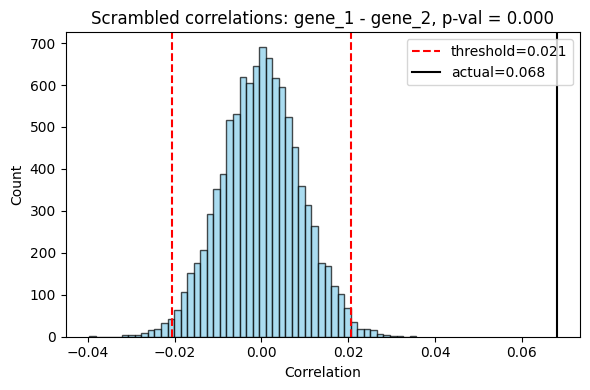

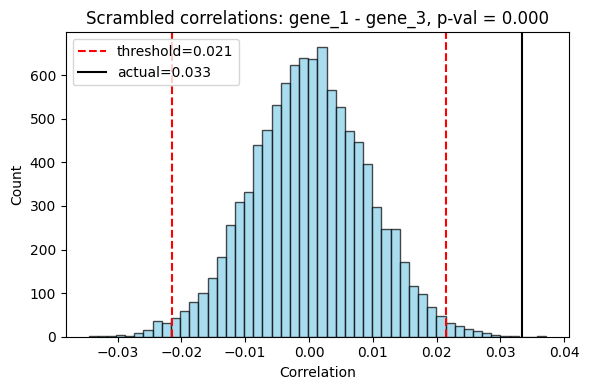

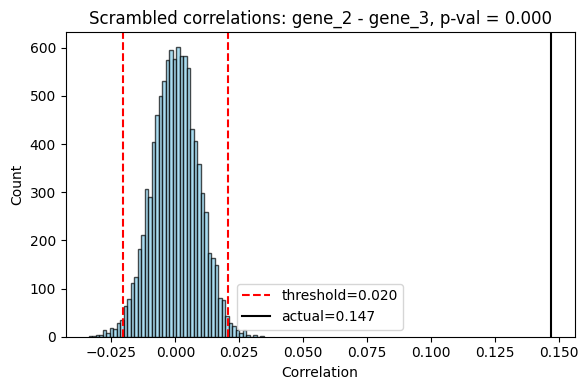

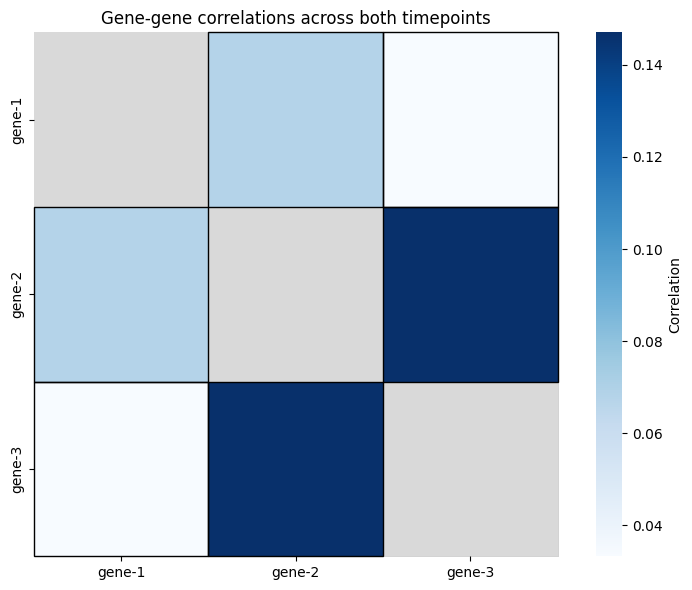

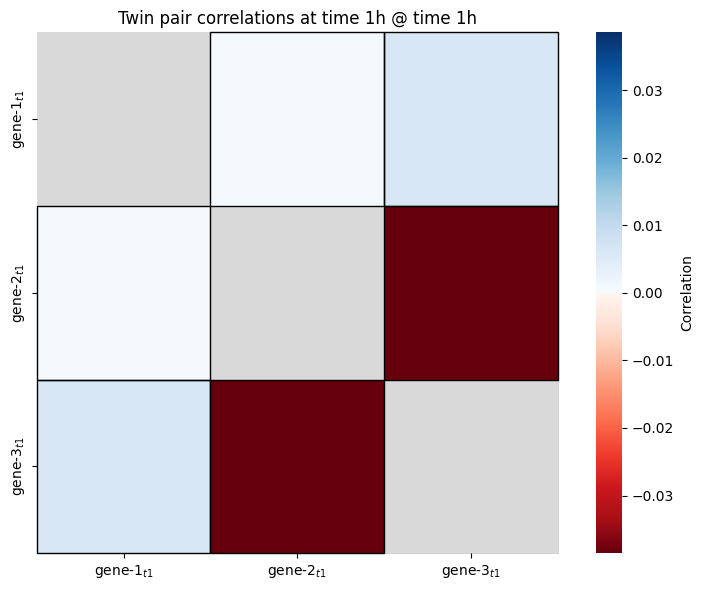

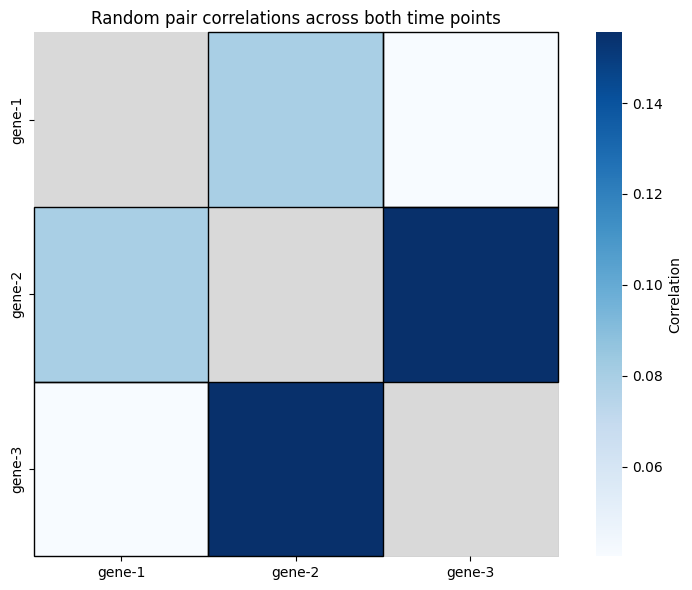

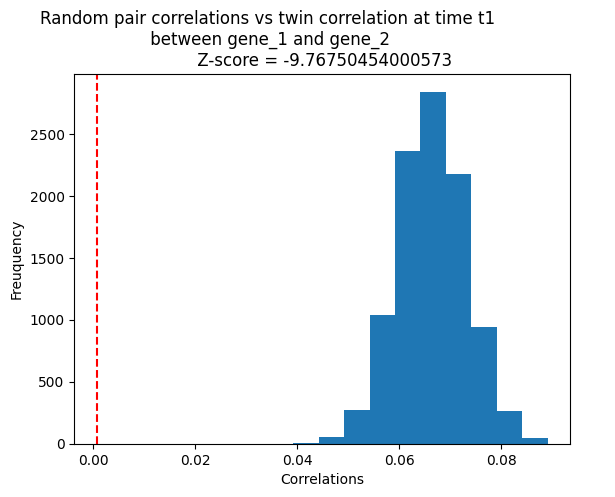

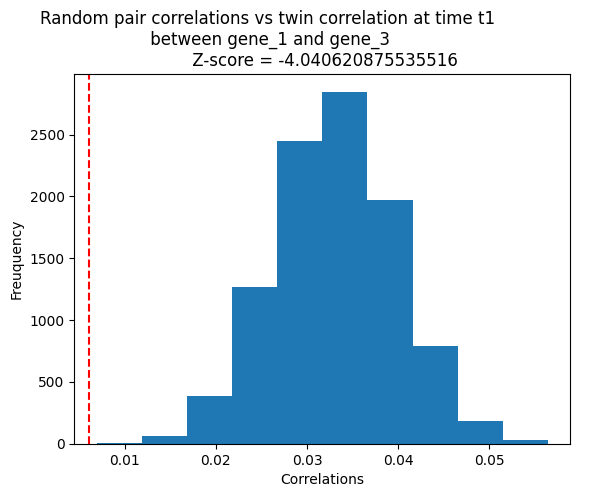

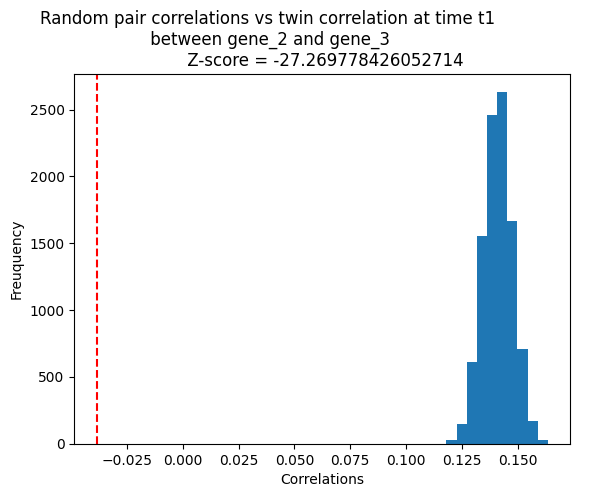

Testing for multiple states. Correlation at time t1 = -0.038533159406500025 and at time t2 = 0.015136203757439364

1. No Regulation
  (none)

2. Single-State Regulation
  gene_1 - gene_2
  gene_1 - gene_3

3. Multiple States (No Regulation)
  (none)

4. Multiple States with Regulation
  gene_2 - gene_3
['gene_1', 'gene_2', 'gene_3']
gene_1 -> gene_1: threshold = 0.046300778616689846, actual = 0.017400276902284583
gene_1 -> gene_2: threshold = 0.04793348112678455, actual = 0.19391327164060795
gene_1 -> gene_3: threshold = 0.046944705469151325, actual = 0.04015781698849112
gene_2 -> gene_1: threshold = 0.04726654770113262, actual = -0.011251039768543056
gene_2 -> gene_2: threshold = 0.04686554525944494, actual = 0.20651001858742704
gene_2 -> gene_3: threshold = 0.04708651588598188, actual = 0.16458176141731445
gene_3 -> gene_1: threshold = 0.046539156859768095, actual = 0.007475580172789585
gene_3 -> gene_2: threshold = 0.04580521332245596, actual = 0.12871082649825497
gene_3 -> gene_3: 

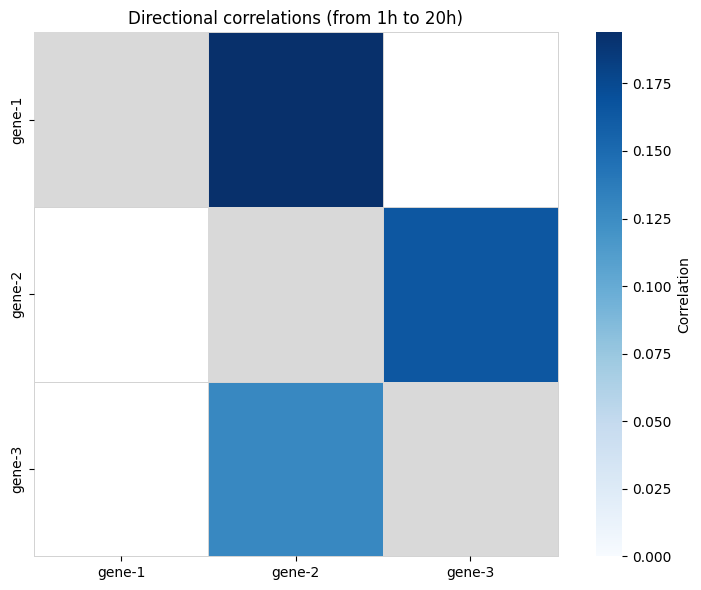

In [23]:
# path_to_simulation_file = [f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_rep_B/df_row_0_1_2_24082025_164300_ncells_6000_A_rep_B_2a6f83e9.csv", "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_rep_B/df_row_12_13_14_24082025_175328_ncells_6000_A_rep_B_68112640.csv"]
# # path_to_simulation_file = ["/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B/df_row_6138_6139_6140_26082025_014059_ncells_6000_A_B_6c7dbf5e.csv", "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B/df_row_67623_67624_27082025_023623_ncells_6000_A_B_6cb08b28.csv"]
# # path_to_simulation_file = ["/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B/df_row_25209_25210_25211_24082025_170151_ncells_6000_A_B_f4697abd.csv", "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B/df_row_38562_38563_38564_25082025_194508_ncells_6000_A_B_a4ade933.csv"]

# twinfer_kwargs = {
#     "path_to_simulation_file": path_to_simulation_file,
#     "base_config": base_config,
#     "t1": 1,  #time [hours] after division when t1 sample is collected
#     "t2": 20, #time [hours] after division when t2 sample is collected
#     "merge":False,
#     "check_for_steady_state": False,
#     "threshold_gene_gene_corr": 0.04, #Use direct threshold (used ONLY if use_scramble is False)
#     "use_scramble": True, #If set to true, set the p_val_threshold_scrambled_gene_correlation;threshold_gene_gene_corr will NOT be used
#     "p_val_threshold_scrambled_gene_correlation": 0.01, #used ONLY if use_scramble is True
#     "show_scrambled_distribution_gene_correlation": True, 
#     "z_score_threshold_two_states": 10, 
#     "p_value_threshold_cross_correlation": 0.01,
#     "plot_correlation_matrices_as_heatmap": True,
#     "have_any_output": True,
#     "seed": 101010,
#     "infer_direction_for_which_edges": "single-state", #can be either single-state or all-edges,
#     "merge_to_multiple_states": True,
#     "n_cores": 4,
#     "remove_twin_structure": False, 
#     "match_sim_details": False
# }

path_to_simulation_file = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_new/df_rows_0_0_0_06122025_224737_ncells_6000_Feed_forward_or_n_2_3_1_98e4c969.csv"
print(path_to_simulation_file)
twinfer_kwargs = {
    "path_to_simulation_file": path_to_simulation_file,
    "base_config": base_config,
    "t1": 1,  #time [hours] after division when t1 sample is collected
    "t2": 20, #time [hours] after division when t2 sample is collected
    "merge_to_multiple_states":False,
    "check_for_steady_state": False,
    "threshold_gene_gene_corr": 0.02, #Use direct threshold (used ONLY if use_scramble is False)
    "use_scramble": True, #If set to true, set the p_val_threshold_scrambled_gene_correlation;threshold_gene_gene_corr will NOT be used
    "p_val_threshold_scrambled_gene_correlation": 0.01, #used ONLY if use_scramble is True
    "show_scrambled_distribution_gene_correlation": True, 
    "z_score_threshold_two_states": 10, 
    "p_value_threshold_cross_correlation": 0.01,
    "plot_correlation_matrices_as_heatmap": True,
    "have_any_output": True,
    "seed": 101010,
    "infer_direction_for_which_edges": "all-edges", #can be either single-state. all-regulation or all-edges,
    "merge": True,
    "n_cores": 8,
    "remove_twin_structure": False
}

correlation_matrices = infer_with_twinfer(**twinfer_kwargs)

/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim/df_rows_0_0_0_0_05122025_140138_ncells_6000_Bi_fan_or_n_2_0_0_6b8ddd18.csv
{'k_on_gene_1': 0.66, 'k_off_gene_1': 8.6, 'mrna_half_life_gene_1': 4, 'protein_half_life_gene_1': 45, 'k_prod_protein_gene_1': 560, 'k_prod_mRNA_gene_1': 2, 'k_deg_mRNA_gene_1': np.float64(0.17328679513998632), 'k_deg_protein_gene_1': np.float64(0.015403270679109895), 'k_on_gene_2': 0.66, 'k_off_gene_2': 8.6, 'mrna_half_life_gene_2': 4, 'protein_half_life_gene_2': 45, 'k_prod_protein_gene_2': 560, 'k_prod_mRNA_gene_2': 2, 'k_deg_mRNA_gene_2': np.float64(0.17328679513998632), 'k_deg_protein_gene_2': np.float64(0.015403270679109895), 'k_on_gene_3': 0.66, 'k_off_gene_3': 8.6, 'mrna_half_life_gene_3': 4, 'protein_half_life_gene_3': 45, 'k_prod_protein_gene_3': 560, 'k_prod_mRNA_gene_3': 2, 'k_deg_mRNA_gene_3': np.float64(0.17328679513998632), 'k_deg_protein_gene_3': np.float64(0.015403270679109895), 'k_on_gene_4': 0.66, 'k_off_gene_4': 8.6, '

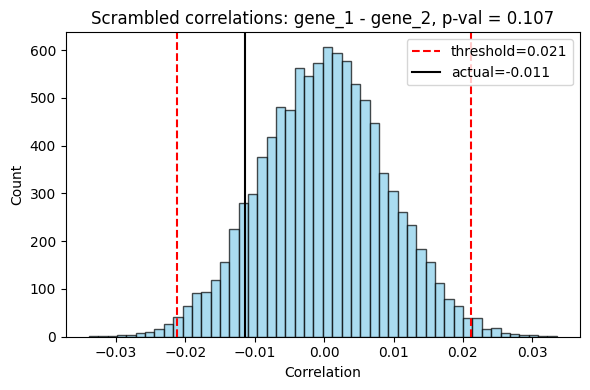

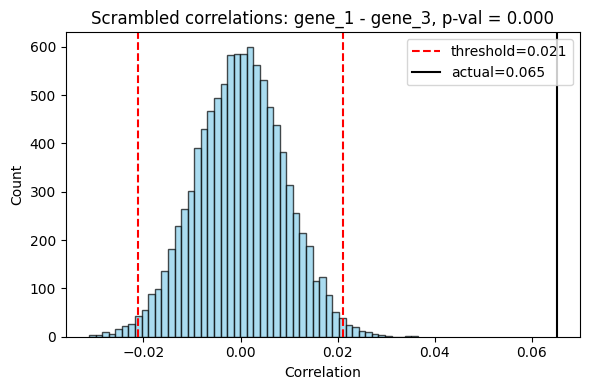

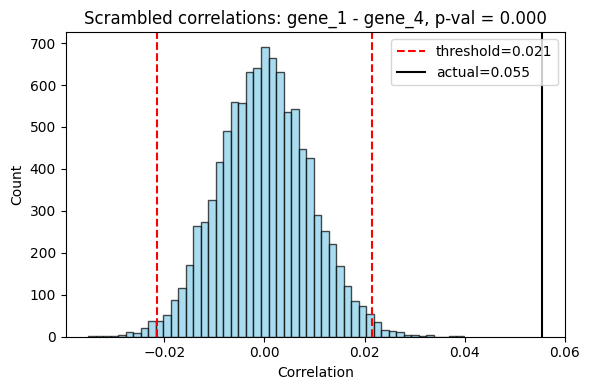

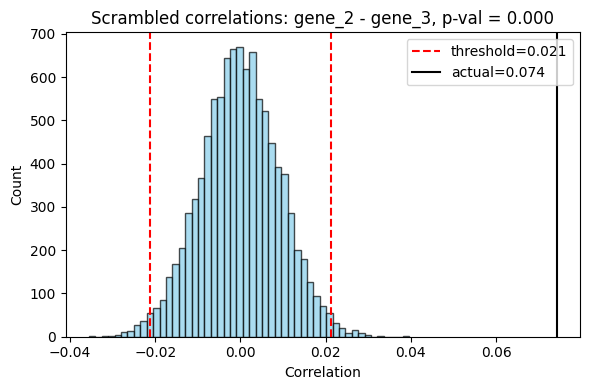

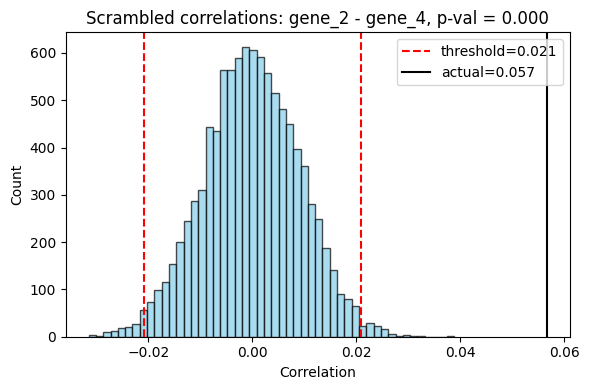

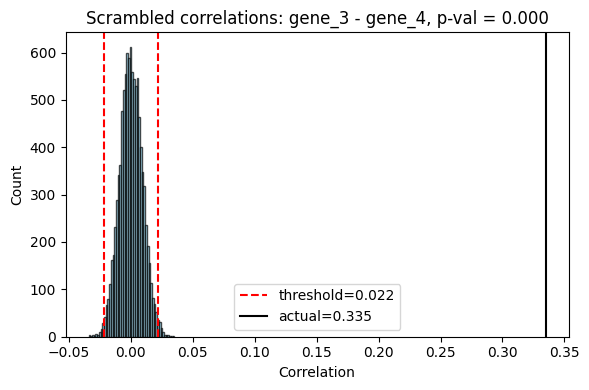

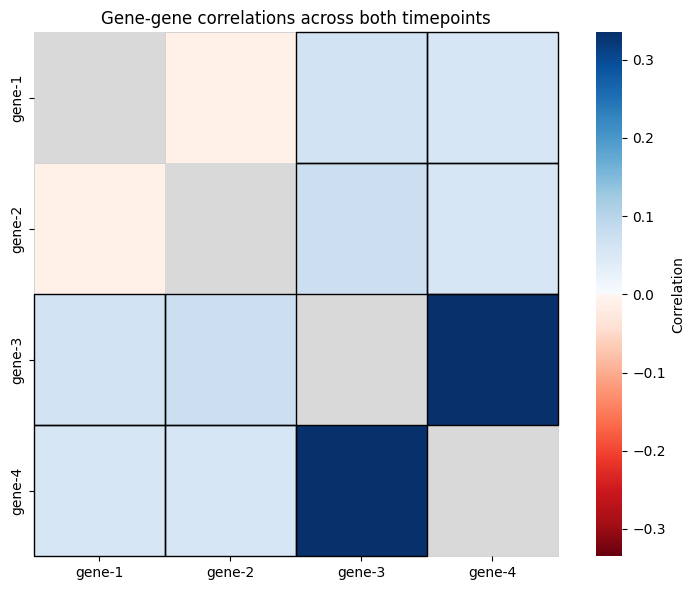

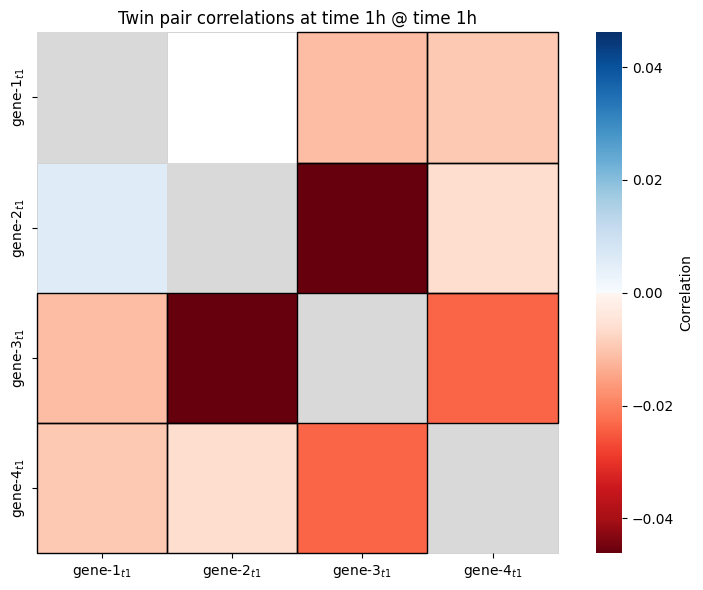

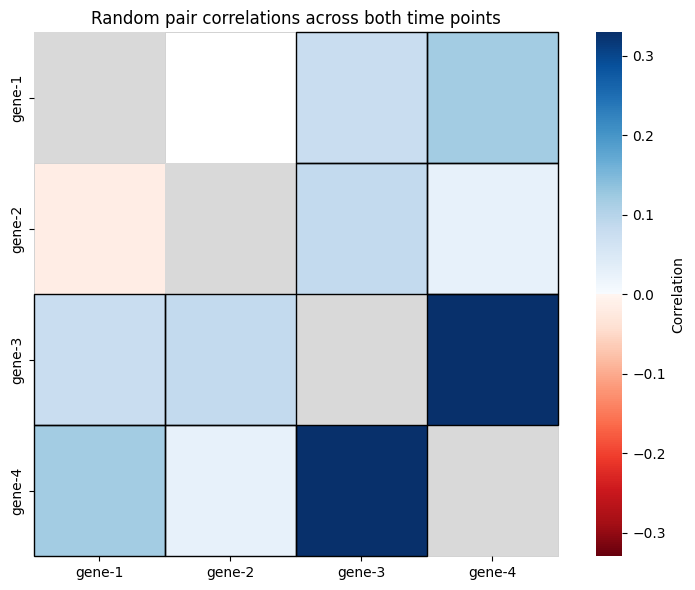

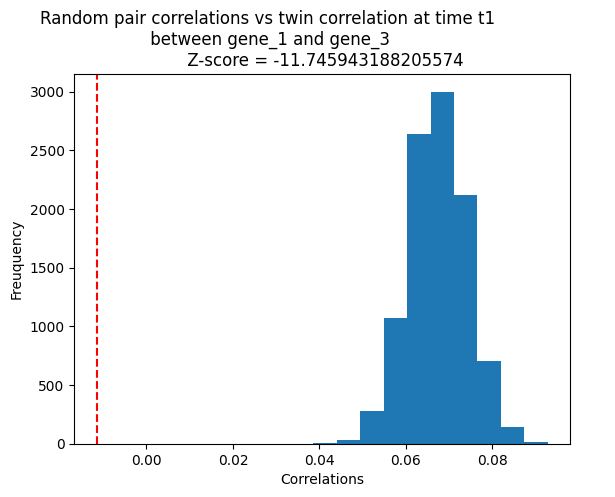

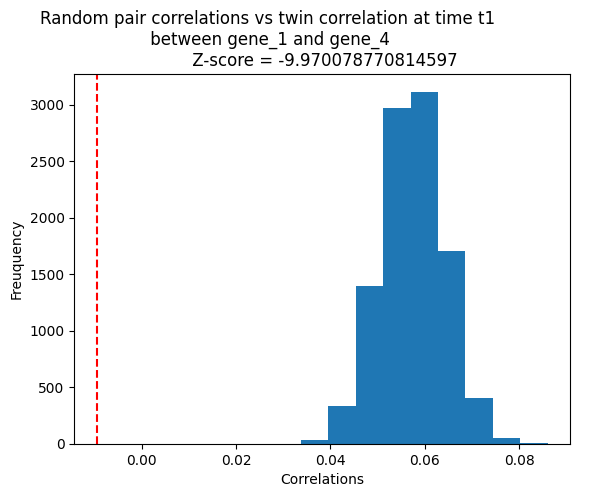

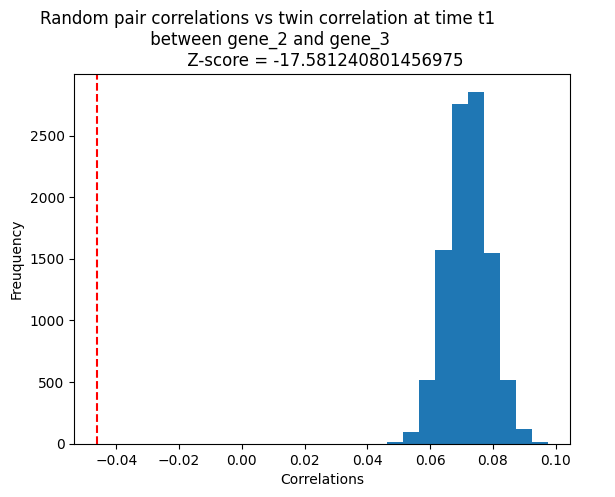

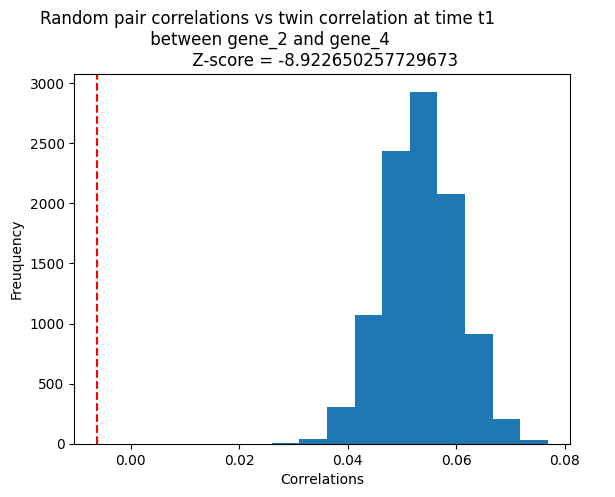

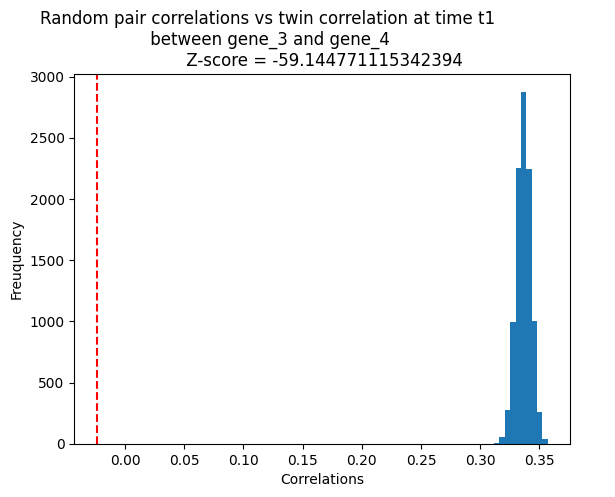

Testing for multiple states. Correlation at time t1 = -0.011459381908267419 and at time t2 = 0.07997426957522756
Testing for multiple states. Correlation at time t1 = -0.04616896496535414 and at time t2 = 0.08561637187598538
Testing for multiple states. Correlation at time t1 = -0.02375791563572407 and at time t2 = 0.10659504447300336

1. No Regulation
  gene_1 - gene_2

2. Single-State Regulation
  gene_1 - gene_4
  gene_2 - gene_4

3. Multiple States (No Regulation)
  (none)

4. Multiple States with Regulation
  gene_1 - gene_3
  gene_2 - gene_3
  gene_3 - gene_4
['gene_1', 'gene_2', 'gene_4']
gene_4 -> gene_4: threshold = 0.04644363349158269, actual = 0.3064132972428538
gene_4 -> gene_1: threshold = 0.04689137613568, actual = 0.002241470668551327
gene_2 -> gene_4: threshold = 0.04772018864164735, actual = 0.13405811936057482
gene_1 -> gene_4: threshold = 0.04677822209717592, actual = 0.1347048551594442
gene_2 -> gene_2: threshold = 0.046174937395520504, actual = 0.02548832008186149


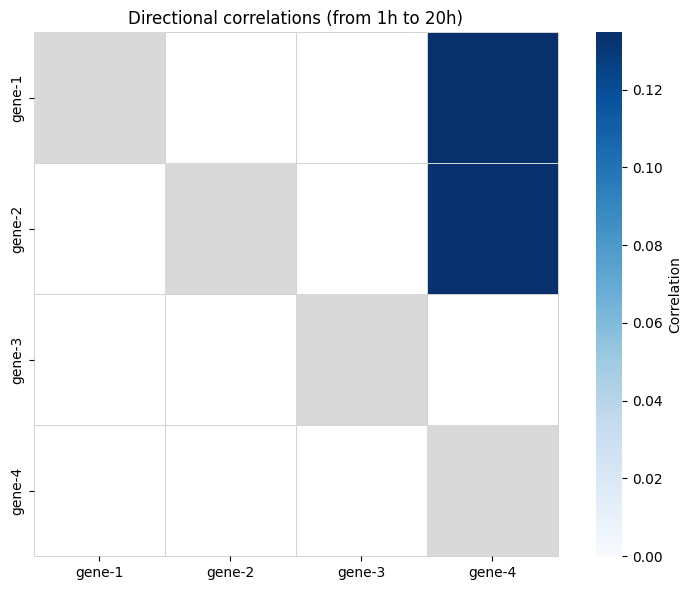

In [11]:
# path_to_simulation_file = [f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_rep_B/df_row_0_1_2_24082025_164300_ncells_6000_A_rep_B_2a6f83e9.csv", "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_rep_B/df_row_12_13_14_24082025_175328_ncells_6000_A_rep_B_68112640.csv"]
# # path_to_simulation_file = ["/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B/df_row_6138_6139_6140_26082025_014059_ncells_6000_A_B_6c7dbf5e.csv", "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B/df_row_67623_67624_27082025_023623_ncells_6000_A_B_6cb08b28.csv"]
# # path_to_simulation_file = ["/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B/df_row_25209_25210_25211_24082025_170151_ncells_6000_A_B_f4697abd.csv", "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B/df_row_38562_38563_38564_25082025_194508_ncells_6000_A_B_a4ade933.csv"]

# twinfer_kwargs = {
#     "path_to_simulation_file": path_to_simulation_file,
#     "base_config": base_config,
#     "t1": 1,  #time [hours] after division when t1 sample is collected
#     "t2": 20, #time [hours] after division when t2 sample is collected
#     "merge":False,
#     "check_for_steady_state": False,
#     "threshold_gene_gene_corr": 0.04, #Use direct threshold (used ONLY if use_scramble is False)
#     "use_scramble": True, #If set to true, set the p_val_threshold_scrambled_gene_correlation;threshold_gene_gene_corr will NOT be used
#     "p_val_threshold_scrambled_gene_correlation": 0.01, #used ONLY if use_scramble is True
#     "show_scrambled_distribution_gene_correlation": True, 
#     "z_score_threshold_two_states": 10, 
#     "p_value_threshold_cross_correlation": 0.01,
#     "plot_correlation_matrices_as_heatmap": True,
#     "have_any_output": True,
#     "seed": 101010,
#     "infer_direction_for_which_edges": "single-state", #can be either single-state or all-edges,
#     "merge_to_multiple_states": True,
#     "n_cores": 4,
#     "remove_twin_structure": False, 
#     "match_sim_details": False
# }

path_to_simulation_file = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim/df_rows_0_0_0_0_05122025_140138_ncells_6000_Bi_fan_or_n_2_0_0_6b8ddd18.csv"
print(path_to_simulation_file)
twinfer_kwargs = {
    "path_to_simulation_file": path_to_simulation_file,
    "base_config": base_config,
    "t1": 1,  #time [hours] after division when t1 sample is collected
    "t2": 20, #time [hours] after division when t2 sample is collected
    "merge_to_multiple_states":False,
    "check_for_steady_state": False,
    "threshold_gene_gene_corr": 0.02, #Use direct threshold (used ONLY if use_scramble is False)
    "use_scramble": True, #If set to true, set the p_val_threshold_scrambled_gene_correlation;threshold_gene_gene_corr will NOT be used
    "p_val_threshold_scrambled_gene_correlation": 0.01, #used ONLY if use_scramble is True
    "show_scrambled_distribution_gene_correlation": True, 
    "z_score_threshold_two_states": 10, 
    "p_value_threshold_cross_correlation": 0.01,
    "plot_correlation_matrices_as_heatmap": True,
    "have_any_output": True,
    "seed": 101010,
    "infer_direction_for_which_edges": "single-state", #can be either single-state or all-edges,
    "merge": True,
    "n_cores": 8,
    "remove_twin_structure": False
}

correlation_matrices = infer_with_twinfer(**twinfer_kwargs)